In [53]:
import numpy as np
import torch
import pandas as pd

all_benchmark_data = pd.read_csv("/lfs/skampere1/0/sttruong/reeval/calibration/all_benchmarks_joined.csv")

In [54]:
all_benchmark_data.head()

,model_name,arc_challenge_q0,arc_challenge_q1,arc_challenge_q2,arc_challenge_q3,arc_challenge_q4,arc_challenge_q5,arc_challenge_q6,arc_challenge_q7,arc_challenge_q8,...,openllm_math_q886,openllm_math_q887,openllm_math_q888,openllm_math_q889,openllm_math_q890,openllm_math_q891,openllm_math_q892,openllm_math_q893,openllm_math_accuracy,openllm_math_total_correct
0,01-ai/Yi-1.5-34B,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.106264,95.0
1,01-ai/Yi-1.5-34B-32K,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.108501,97.0
2,01-ai/Yi-1.5-34B-Chat,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.177852,159.0
3,01-ai/Yi-1.5-34B-Chat-16K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.134228,120.0
4,01-ai/Yi-1.5-6B,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.038031,34.0


In [55]:
# Debug version
data_clean = all_benchmark_data.drop('model_name', axis=1)

# Find binary columns
binary_cols = []
for col in data_clean.columns:
    unique_vals = data_clean[col].dropna().unique()
    if all(val in [0.0, 1.0] for val in unique_vals):
        binary_cols.append(col)
# Keep only binary columns
data_binary = data_clean[binary_cols]

# Convert ALL columns to float64 (including boolean columns)
data_binary = data_binary.astype('float64')

# Now convert to tensor
data_tensor = torch.tensor(data_binary.values, dtype=torch.float32)


In [67]:
data_tensor

tensor([[1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [nan, nan, nan,  ..., 0., 0., 0.]])

In [ ]:
import pandas as pd
import numpy as np
import torch
import pickle
import os
import json
import gc
from torch.distributions import Bernoulli
from torch.optim import LBFGS
from tqdm import tqdm
from scipy.stats import pearsonr
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import Manager
import multiprocessing as mp

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tueplots import bundles
bundles.icml2024()

from torchmetrics import AUROC
auroc = AUROC(task="binary")

import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(0)

device = "cuda:4"

def visualize_response_matrix(results, value, filename):
    # Extract the groups labels in the order of the columns
    group_values = results.columns.get_level_values("scenario")

    # Identify the boundaries where the group changes
    boundaries = []
    for i in range(1, len(group_values)):
        if group_values[i] != group_values[i - 1]:
            boundaries.append(i - 0.5)  # using 0.5 to place the line between columns

    # Visualize the results with a matrix: red is 0, white is -1 and blue is 1
    cmap = mcolors.ListedColormap(["white", "red", "blue"])
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Calculate midpoints for each group label
    groups_list = list(group_values)
    group_names = []
    group_midpoints = []
    current_group = groups_list[0]
    start_index = 0
    for i, grp in enumerate(groups_list):
        if grp != current_group:
            midpoint = (start_index + i - 1) / 2.0
            group_names.append(current_group)
            group_midpoints.append(midpoint)
            current_group = grp
            start_index = i
    # Add the last group
    midpoint = (start_index + len(groups_list) - 1) / 2.0
    group_names.append(current_group)
    group_midpoints.append(midpoint)

    # Define the minimum spacing between labels (e.g., 100 units)
    min_spacing = 100
    last_label_pos = -float("inf")
    # Plot the matrix
    with plt.rc_context(bundles.icml2024(usetex=True, family="serif")):
        fig, ax = plt.subplots(figsize=(20, 10))
        cax = ax.matshow(value, aspect="auto", cmap=cmap, norm=norm)

        # Add vertical lines at each boundary
        for b in boundaries:
            ax.axvline(x=b, color="black", linewidth=0.25, linestyle="--", alpha=0.5)
        
        # Add group labels above the matrix, only if they're spaced enough apart
        for name, pos in zip(group_names, group_midpoints):
            if pos - last_label_pos >= min_spacing:
                ax.text(pos, -5, name, ha='center', va='bottom', rotation=90, fontsize=3)
                last_label_pos = pos

        # Add model labels on the y-axis
        ax.set_yticks(range(len(results.index)))
        ax.set_yticklabels(results.index, fontsize=3)

        # Add a colorbar
        cbar = plt.colorbar(cax)
        cbar.set_ticks([-1, 0, 1])
        cbar.set_ticklabels(["-1", "0", "1"])
        plt.savefig(filename, dpi=600, bbox_inches="tight")
        plt.close()=[[[]]]

def trainer(parameters, optim, closure, n_iter=100, verbose=True):
    pbar = tqdm(range(n_iter)) if verbose else range(n_iter)
    for iteration in pbar:
        if iteration > 0:
            previous_parameters = [p.clone() for p in parameters]
            previous_loss = loss.clone()
        
        loss = optim.step(closure)
        
        if iteration > 0:
            d_loss = (previous_loss - loss).item()
            d_parameters = sum(
                torch.norm(prev - curr, p=2).item()
                for prev, curr in zip(previous_parameters, parameters)
            )
            grad_norm = sum(torch.norm(p.grad, p=2).item() for p in parameters if p.grad is not None)
            if verbose:
                pbar.set_postfix({"grad_norm": grad_norm, "d_parameter": d_parameters, "d_loss": d_loss})
            
            if d_loss < 1e-5 and d_parameters < 1e-5 and grad_norm < 1e-5:
                break
    return parameters

def compute_auc(probs, data, train_idtor, test_idtor):
    train_probs = probs[train_idtor.bool()]
    test_probs = probs[test_idtor.bool()]
    train_labels = data[train_idtor.bool()]
    test_labels = data[test_idtor.bool()]
    
    train_auc = auroc(train_probs, train_labels)
    test_auc = auroc(test_probs, test_labels)
    print(f"train auc: {train_auc}")
    print(f"test auc: {test_auc}")
    
    return train_auc, test_auc

def compute_cttcorr(probs, data, train_idtor, test_idtor):
    train_probs  = probs.clone()
    test_probs   = probs.clone()
    train_labels = data.clone()
    test_labels  = data.clone()

    train_mask = ~train_idtor.bool()
    train_probs[train_mask]  = float('nan')
    train_labels[train_mask] = float('nan')

    test_mask = ~test_idtor.bool()
    test_probs[test_mask]   = float('nan')
    test_labels[test_mask]  = float('nan')
    
    train_prob_ctt = torch.nanmean(train_probs, dim=1).detach().cpu().numpy()
    train_label_ctt = torch.nanmean(train_labels, dim=1).detach().cpu().numpy()
    train_mask = ~np.isnan(train_prob_ctt) & ~np.isnan(train_label_ctt)
    train_cttcorr = pearsonr(train_prob_ctt[train_mask], train_label_ctt[train_mask]).statistic
    
    test_prob_ctt = torch.nanmean(test_probs, dim=1).detach().cpu().numpy()
    test_label_ctt = torch.nanmean(test_labels, dim=1).detach().cpu().numpy()
    test_mask = ~np.isnan(test_prob_ctt) & ~np.isnan(test_label_ctt)
    test_cttcorr = pearsonr(test_prob_ctt[test_mask], test_label_ctt[test_mask]).statistic
    
    print(f"train cttcorr: {train_cttcorr}")
    print(f"test cttcorr: {test_cttcorr}")

    return train_cttcorr, test_cttcorr

mkdir -p failed for path /dfs/user/sttruong/.cache/matplotlib: [Errno 13] Permission denied: '/dfs/user/sttruong'
Matplotlib created a temporary cache directory at /tmp/user/21130/matplotlib-z_ygqhvx because there was an issue with the default path (/dfs/user/sttruong/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2025-08-25 21:17:27.909531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756181847.924226 4010146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756181847.928572 4010146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS 

In [58]:
results.values

<function Tensor.values>

In [60]:
with open(f"../data/resmat.pkl", "rb") as f:
    results = pickle.load(f)
results = data_tensor
# data_withnan, missing=nan
# data_withneg1, missing=-1
# data_with0, missing=0
data_withnan = torch.tensor(results, dtype=torch.float, device=device)

data_withneg1 = data_withnan.nan_to_num(nan=-1.0)
data_idtor = (data_withneg1 != -1).to(float)
data_with0 = data_withneg1 * data_idtor # -1 -> 0
n_test_takers, n_items = data_with0.shape
scenarios = results.columns.get_level_values("scenario").unique()

# save dict
metric_results = defaultdict(dict)

AttributeError: 'Tensor' object has no attribute 'columns'

In [5]:
# load this file: resmat.pt
resmat = torch.load("../resmat.pt")
P = resmat["data_tensor"].mean(-1)
P1 = P[0]


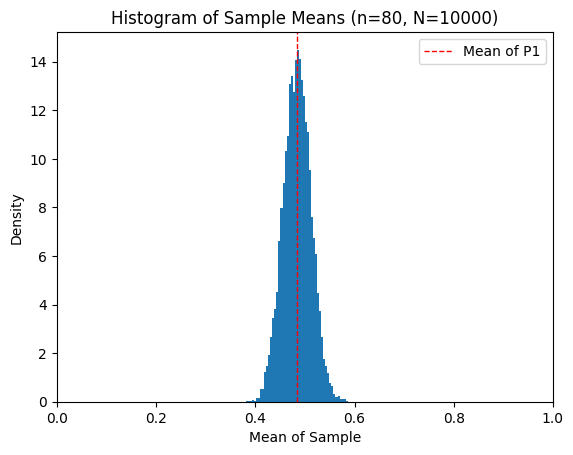

In [6]:
# sampling without replacement for P1 with sample size of 50. Repeat 1000 times
# for each sample, compute the mean
# plot a histogram of the means

sample_size = 80
n_samples = 10000
means = []
for _ in range(n_samples):
    sample = P1[torch.randperm(P1.shape[0])[:sample_size]]
    means.append(sample.mean().item())
plt.hist(means, bins=50, density=True)
plt.xlabel("Mean of Sample")
plt.ylabel("Density")
plt.title(f"Histogram of Sample Means (n={sample_size}, N={n_samples})")
# x axis limits to 0 1
plt.xlim(0, 1)

# Plot the mean of P1
plt.axvline(P1.mean().item(), color='red', linestyle='dashed', linewidth=1, label='Mean of P1')
plt.legend()
plt.show()    


In [7]:
vis_resmat_dir = "../result/visualize_resmat"
os.makedirs(vis_resmat_dir, exist_ok=True)

# overall stats
print("Number of test takers:", results.shape[0])
print("Number of items:", results.shape[1])
print("Number of scenarios:", results.columns.get_level_values("scenario").nunique())
visualize_response_matrix(results, results, f"{vis_resmat_dir}/resmat_all")

# count the number of items and test takers in each dataset
scenario_counts = {}
for scenario in sorted(scenarios):
    mask = results.columns.get_level_values("scenario") == scenario
    sub_results = results.loc[:, mask]
    scenario_counts[scenario] = {
        "n_items": sub_results.shape[1],
        "n_test_takers": sub_results.notna().any(axis=1).sum()
    }
    print(f"{scenario}: {scenario_counts[scenario]['n_test_takers']} test takers, {scenario_counts[scenario]['n_items']} items")
    # visualize_response_matrix(sub_results, sub_results, f"{vis_resmat_dir}/resmat_{scenario}")

Number of test takers: 183
Number of items: 78712
Number of scenarios: 22
air_bench_2024: 41 test takers, 4985 items
babi_qa: 70 test takers, 3461 items
bbq: 42 test takers, 999 items
boolq: 67 test takers, 3316 items
civil_comments: 67 test takers, 29407 items
commonsense: 91 test takers, 498 items
dyck_language_np=3: 69 test takers, 500 items
entity_data_imputation: 67 test takers, 395 items
entity_matching: 67 test takers, 1396 items
gsm: 90 test takers, 997 items
imdb: 67 test takers, 3530 items
legal_support: 69 test takers, 594 items
legalbench: 91 test takers, 1997 items
lsat_qa: 69 test takers, 454 items
math: 91 test takers, 436 items
med_qa: 91 test takers, 998 items
mmlu: 79 test takers, 13223 items
raft: 67 test takers, 1336 items
synthetic_reasoning: 69 test takers, 2234 items
thai_exam: 40 test takers, 557 items
truthful_qa: 67 test takers, 1888 items
wikifact: 67 test takers, 5511 items


In [8]:
# overall mean
naive_prediction_0 = torch.nanmean(data_withnan)
naive_prediction_0 = naive_prediction_0.expand(data_withnan.shape[0], data_withnan.shape[1])
auc_train_0 = auroc(naive_prediction_0[data_idtor.bool()], data_withnan[data_idtor.bool()]).item()
print(f"Naive auc 0: {auc_train_0}")

# question difficulty average
naive_prediction_1 = torch.nanmean(data_withnan, dim=0)
naive_prediction_1 = naive_prediction_1[None, :].expand(data_withnan.shape[0], data_withnan.shape[1])
auc_train_1_1 = auroc(naive_prediction_1[data_idtor.bool()], data_withnan[data_idtor.bool()]).item()
print(f"Naive auc 1.1: {auc_train_1_1}")

# test taker average
naive_prediction_1 = torch.nanmean(data_withnan, dim=1)
naive_prediction_1 = naive_prediction_1[:, None].expand(data_withnan.shape[0], data_withnan.shape[1])
auc_train_1_2 = auroc(naive_prediction_1[data_idtor.bool()], data_withnan[data_idtor.bool()]).item()
print(f"Naive auc 1.2: {auc_train_1_2}")

Naive auc 0: 0.5
Naive auc 1.1: 0.8070003986358643
Naive auc 1.2: 0.6573556065559387


In [63]:
# data_idtor = train_idtor + test_idtor
# apply random train/test mask to the matrix, and ensure no one row or column is fully masked
valid_condition = False
trial = 0
while not valid_condition:
    train_idtor = torch.bernoulli(data_idtor * 0.8).int()
    test_idtor = data_idtor - train_idtor
    valid_condition = (train_idtor.sum(axis=1) != 0).all() and (train_idtor.sum(axis=0) != 0).all()
    print(f"trial {trial} valid condition: {valid_condition}")
    trial += 1

# fit z
B = 50000
optimized_zs = []
thetas_nuisance = torch.randn(150, n_test_takers, device=device)
for i in tqdm(range(0, n_items, B)):
    data_batch = data_with0[:, i:i+B]
    train_idtor_batch = train_idtor[:, i:i+B]
    current_B = data_batch.shape[1]
    z_i = torch.randn(current_B, requires_grad=True, device=device)
    optim_z_i = LBFGS([z_i], lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")
    def closure_z_i():
        optim_z_i.zero_grad()
        probs = torch.sigmoid(thetas_nuisance[:, :, None] + z_i[None, None, :])
        loss = -(Bernoulli(probs=probs).log_prob(data_batch)*train_idtor_batch).mean()
        loss.backward()
        return loss
    z_i_optimized = trainer([z_i], optim_z_i, closure_z_i)[0].detach()
    optimized_zs.append(z_i_optimized)
zs = torch.cat(optimized_zs)

# fit theta
thetas = torch.randn(n_test_takers, requires_grad=True, device=device)
optim_theta = LBFGS([thetas], lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")
def closure_theta():
    optim_theta.zero_grad()
    probs = torch.sigmoid(thetas[:, None] + zs[None, :])
    loss = -(Bernoulli(probs=probs).log_prob(data_with0)*train_idtor).mean()
    loss.backward()
    return loss
thetas = trainer([thetas], optim_theta, closure_theta)[0]

# calculate metrics
probs = torch.sigmoid(thetas[:, None] + zs[None, :])

train_auc, test_auc = compute_auc(probs, data_with0, train_idtor, test_idtor)
metric_results["combined_data"]["train_auc"] = train_auc.item()
metric_results["combined_data"]["test_auc"] = test_auc.item()

train_cttcorr, test_cttcorr = compute_cttcorr(probs, data_with0, train_idtor, test_idtor)
metric_results["combined_data"]["train_cttcorr"] = train_cttcorr.item()
metric_results["combined_data"]["test_cttcorr"] = test_cttcorr.item()

del optim_theta, thetas, z_i, thetas_nuisance, optim_z_i
gc.collect()
torch.cuda.empty_cache()

trial 0 valid condition: True


 11%|█         | 11/100 [00:00<00:02, 30.25it/s, grad_norm=2.48e-7, d_parameter=0, d_loss=4.81e-10]      


train auc: 0.844719648361206
test auc: 0.8421234488487244
train cttcorr: 0.9999999984983345
test cttcorr: 0.9981463112397106


In [68]:
# data_idtor = train_idtor + test_idtor
# apply random train/test mask to the matrix, and ensure no one row or column is fully masked
valid_condition = False
trial = 0
while not valid_condition:
    train_idtor = torch.bernoulli(data_idtor * 0.8).int()
    test_idtor = data_idtor - train_idtor
    valid_condition = (train_idtor.sum(axis=1) != 0).all() and (train_idtor.sum(axis=0) != 0).all()
    print(f"trial {trial} valid condition: {valid_condition}")
    trial += 1

# fit z
B = 50000
optimized_zs = []

dim = 2

# shape(thetas_nuisance): MC_sample * test_taker * dim
thetas_nuisance = torch.randn(100, n_test_takers, dim, device=device) 
for i in tqdm(range(0, n_items, B)):
    data_batch = data_with0[:, i:i+B]
    train_idtor_batch = train_idtor[:, i:i+B]
    current_B = data_batch.shape[1]
    # shape(z_i): batch_size * dim
    z_i = torch.randn(current_B, dim, requires_grad=True, device=device)
    optim_z_i = LBFGS([z_i], lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")
    def closure_z_i():
        optim_z_i.zero_grad()
        z_ = z_i[None, :, :].expand(100,-1,-1)
        probs = torch.sigmoid(torch.einsum('mtk,mbk->mtb', thetas_nuisance, z_))
        loss = -(Bernoulli(probs=probs).log_prob(data_batch)*train_idtor_batch).mean()
        loss.backward()
        return loss
    
    z_i_optimized = trainer([z_i], optim_z_i, closure_z_i)[0].detach()
    optimized_zs.append(z_i_optimized)
zs = torch.cat(optimized_zs)

thetas = torch.randn(n_test_takers, dim,requires_grad=True, device=device)
optim_theta = LBFGS([thetas], lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")
def closure_theta():
    optim_theta.zero_grad()
    # probs = torch.sigmoid(thetas[:, None] + zs[None, :])
    probs = torch.sigmoid(torch.einsum('tk,bk->tb',thetas, zs))
    loss = -(Bernoulli(probs=probs).log_prob(data_with0)*train_idtor).mean()
    loss.backward()
    return loss
thetas = trainer([thetas], optim_theta, closure_theta)[0]
probs = torch.sigmoid(torch.einsum('tk,bk->tb',thetas, zs))
train_auc, test_auc = compute_auc(probs, data_with0, train_idtor, test_idtor)
metric_results["combined_data"]["train_auc"] = train_auc.item()
metric_results["combined_data"]["test_auc"] = test_auc.item()

train_cttcorr, test_cttcorr = compute_cttcorr(probs, data_with0, train_idtor, test_idtor)
metric_results["combined_data"]["train_cttcorr"] = train_cttcorr.item()
metric_results["combined_data"]["test_cttcorr"] = test_cttcorr.item()

del optim_theta, thetas, z_i, thetas_nuisance, optim_z_i
gc.collect()
torch.cuda.empty_cache()

# fit theta

trial 0 valid condition: True


  2%|▏         | 2/100 [00:00<00:05, 17.69it/s, grad_norm=7.4e-7, d_parameter=0, d_loss=4.3e-6]   


train auc: 0.7374960780143738
test auc: 0.7322237491607666
train cttcorr: 0.8293587256706381
test cttcorr: 0.8442626460291447


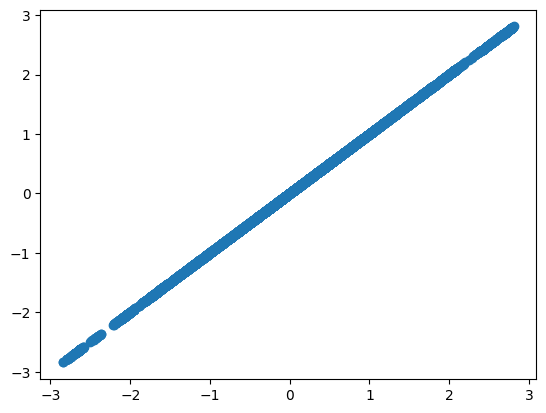

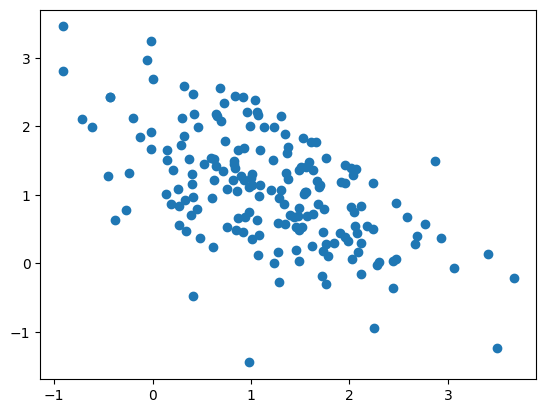

In [18]:
zs_np = zs.cpu().detach().numpy()
thetas_np = thetas.cpu().detach().numpy()
plt.scatter(zs_np[:, 0], zs_np[:, 1])
plt.show()

plt.scatter(thetas_np[:, 0], thetas_np[:, 1])
plt.show()


In [30]:
thetas_nuisance = torch.randn(150, n_test_takers, dim, device=device)
z_i = torch.randn(current_B, dim, requires_grad=True, device=device)
torch.sigmoid(torch.einsum('mtk,bk->mtb', thetas_nuisance, z_i)).shape

torch.Size([150, 183, 28712])

In [35]:
thetas_nuisance[:3,:3,:3]

tensor([[[-1.6499e-02, -5.5412e-01,  4.0756e-01],
         [ 1.2286e+00, -4.1252e-01,  2.5761e+00],
         [ 6.9260e-01, -1.9231e+00, -5.8231e-01]],

        [[-1.3845e+00,  5.8161e-01,  1.8253e-01],
         [ 1.2359e-01,  4.5117e-01,  3.8884e-01],
         [ 3.6352e-01,  1.0633e+00, -1.8851e-03]],

        [[ 4.9209e-01, -1.0555e+00, -1.3573e+00],
         [-7.2999e-01, -1.9504e+00,  1.0174e+00],
         [ 1.5445e-01,  6.2330e-01,  1.5136e+00]]], device='cuda:4')

In [36]:
z_i[:3,:3]

tensor([[ 0.2401,  1.4084,  0.8415],
        [-1.1040, -0.3277,  0.1300],
        [-0.5392,  1.6629,  1.0722]], device='cuda:4',
       grad_fn=<SliceBackward0>)

In [ ]:
torch.sigmoid(torch.einsum('mtk,bk->mtb', thetas_nuisance, z_i))

train auc: 0.6939191818237305
test auc: 0.6711156964302063
train cttcorr: 0.7837330562065564
test cttcorr: 0.7847647534279667


In [11]:
thetas

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [24]:
torch.cat(optimized_zs).shape

torch.Size([78712, 2])

In [ ]:
import subprocess
import torch
from torchmetrics import AUROC
import pandas as pd
auroc = AUROC(task="binary")


2025-08-28 08:58:07.382217: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756396687.397982 1121880 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756396687.402616 1121880 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756396687.417196 1121880 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756396687.417209 1121880 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756396687.417211 1121880 computation_placer.cc:177] computation placer alr

In [ ]:
# Run your R script
subprocess.run(["Rscript", "cfa.R"], check=True)

print("R script finished, check Y.csv, U.csv, and V.csv")

This is lavaan 0.6-19
lavaan is FREE software! Please report any bugs.


R script finished, check Y.csv, U.csv, and V.csv


In [ ]:
U_df = pd.read_csv("U.csv")
V_df = pd.read_csv("V.csv")
Y_df = pd.read_csv("Y.csv")
device = "cuda:0"
Y = torch.tensor(Y_df.values, dtype=torch.float32, device=device)  # (N, J)
U = torch.tensor(U_df.values, dtype=torch.float32, device=device)  # (N, K)
V = torch.tensor(V_df.values, dtype=torch.float32, device=device)  # (J, K)

In [31]:
probs = torch.sigmoid(U @ V.T)


In [36]:
auroc(probs,Y)

tensor(0.8655, device='cuda:0')